# DASC 5431 Assignment 1: Classification Model
<u>Group 4</u>: Greg Ige, Meet Paghadar, Bobby Bagley

# Question 1: Data Strategy and k-Nearest Neighbors (kNN)

Using the **Dry Bean dataset**, perform a classification analysis by following these implementation requirements, all random seed or random state set as $2026$:

1. Data Partitioning and Timing:
    Load the dataset and split it into training (70%), validation (20%), and testing (10%) sets using ```train_test_split``` with ```stratify=y```. Print the shape of each partition.

    Requirement: Use the ```%%time``` command to record the model training time for every fitting operation in this assignment.
    
    Analytical Task: Explain why stratification is essential for maintaining consistent class distributions across partitions.

2. KNN Implementation:
    * Use ```ConvexArea``` and ```Extent``` as your input features.
    * Implement ```StandardScaler``` to standardize these features.
    * Visual Comparison: To see the impact of scaling, fit a kNN model () on unscaled data and then on standardized data. Plot the decision boundaries for both.
    * Technical Justification: Analyze why failing to standardize features with different numeric ranges negatively impacts distance-based calculations like Euclidean or Minkowski distance.

3. Hyperparameter tuning:
    Evaluate kNN performance for $𝑘 ∈ {3,5,7,9}$ using the validation set. Identify the "best" and plot its final decision boundary.

## Quick EDA

In [1]:
# Import ALL libraries
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB as GNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier

RANDOM_STATE = 2026
np.random.seed(RANDOM_STATE)

In [2]:
# Read the dataset from a Excel file
df = pd.read_excel('/content/Dry_Bean_Dataset.xlsx') # Enter your path to the data set herr
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


Do some quick EDA to get familiar with the dataset. Nothing fancy:

* Get shape.
* View columns.
* Check for null, NaN, *missing* values.
* Read the data dictionary that came with the dataset.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [4]:
df['Class'].unique()

array(['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON'],
      dtype=object)

There are 7 unique classes of beans in this dataset:

**'SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON'**

<u>Attribute Information:</u>

1.) Area (A): The area of a bean zone and the number of pixels within its boundaries.

2.) Perimeter (P): Bean circumference is defined as the length of its border.

3.) Major axis length (L): The distance between the ends of the longest line that can be drawn from a bean.

4.) Minor axis length (l): The longest line that can be drawn from the bean while standing perpendicular to the main axis.

5.) Aspect ratio (K): Defines the relationship between L and l.

6.) Eccentricity (Ec): Eccentricity of the ellipse having the same moments as the region.

7.) Convex area (C): Number of pixels in the smallest convex polygon that can contain the area of a bean seed.

8.) Equivalent diameter (Ed): The diameter of a circle having the same area as a bean seed area.

9.) Extent (Ex): The ratio of the pixels in the bounding box to the bean area.

10.)Solidity (S): Also known as convexity. The ratio of the pixels in the convex shell to those found in beans.

11.)Roundness (R): Calculated with the following formula: (4piA)/(P^2)

12.)Compactness (CO): Measures the roundness of an object: Ed/L

13.)ShapeFactor1 (SF1)

14.)ShapeFactor2 (SF2)

15.)ShapeFactor3 (SF3)

16.)ShapeFactor4 (SF4)

17.)Class (Seker, Barbunya, Bombay, Cali, Dermosan, Horoz and Sira)

We will be focusing on two features: ```ConvexArea``` and ```Extent```.

I want to check if there is any relationship between them.

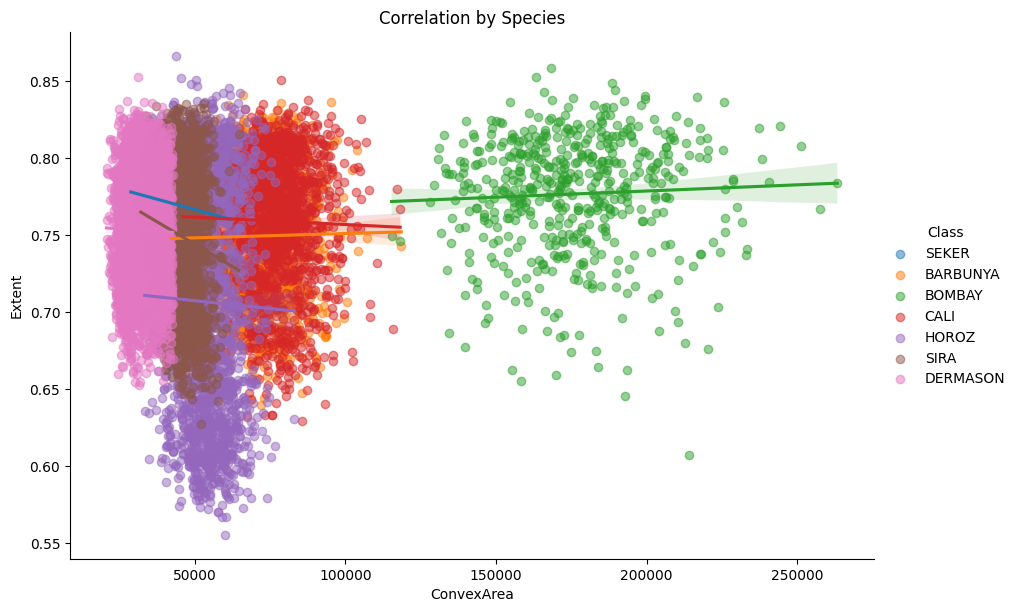

In [5]:
# Check the relationship between two features ConvexArea and Extent with a lmplot
sns.lmplot(
    data=df,
    x='ConvexArea',
    y='Extent',
    hue='Class',
    height=6,
    aspect=1.5,
    scatter_kws={'alpha':0.5}
)

plt.title('Correlation by Species')
plt.show()

For all ```Class``` of bean, save for *Sira*, there appears to be no/very weak correlation between ```Extent``` and ```ConvexArea```.

*Sira* appears to have a negative relationship between ```Extent``` and ```ConvexArea```.

Explore ```Class``` and distribution of select input features.

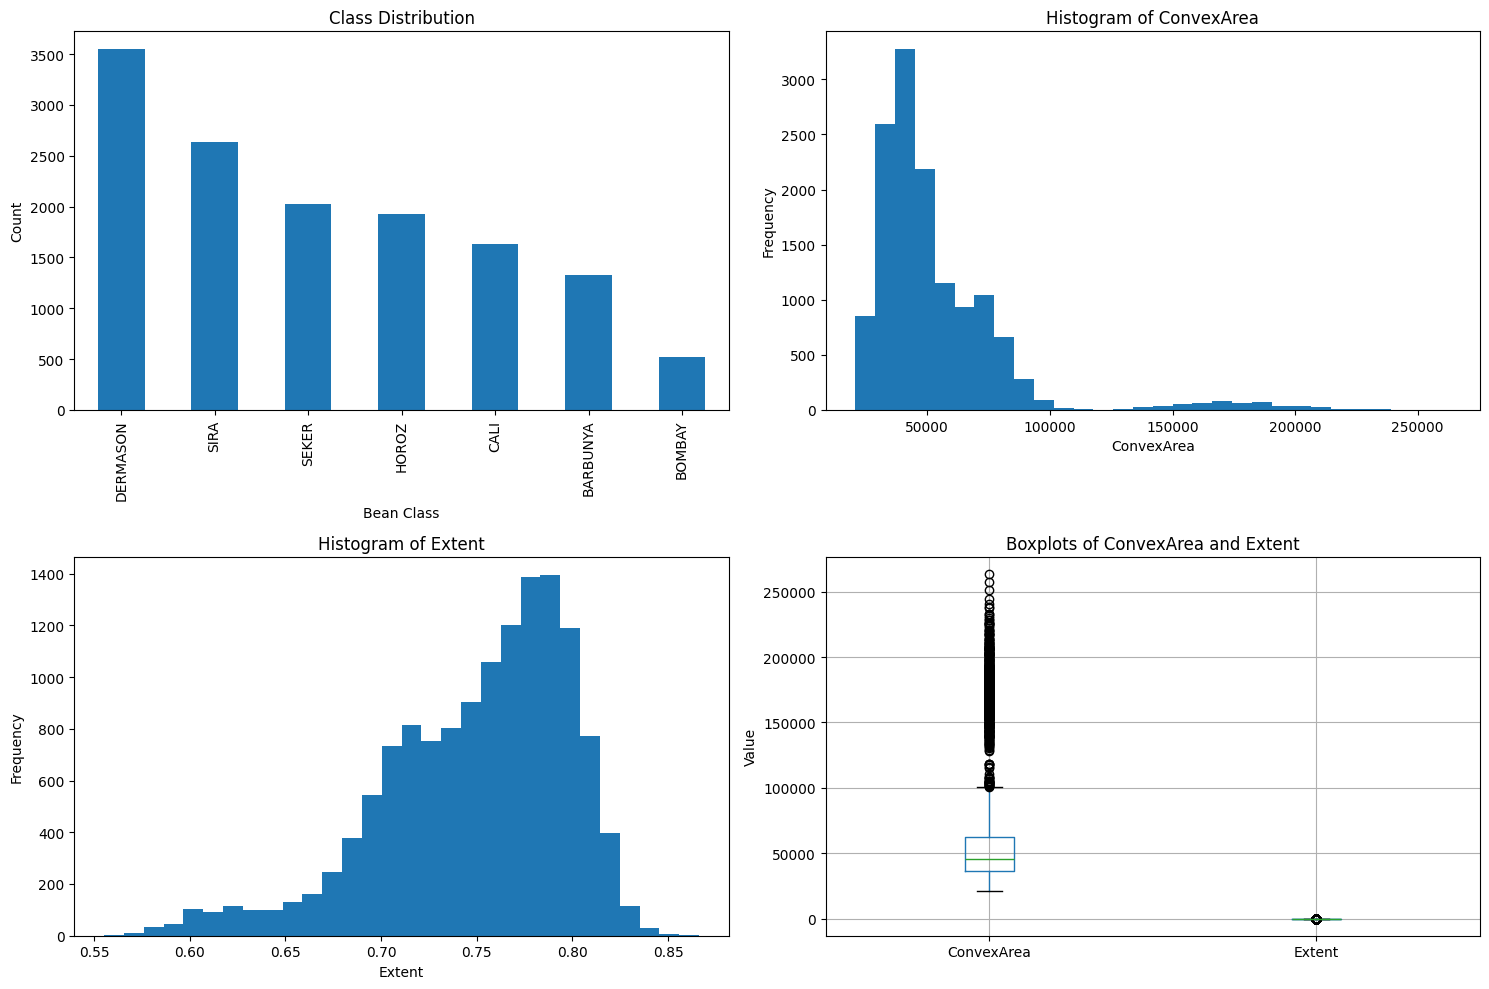

In [6]:
## EDA CLASS DISTRIBUTION

# Class Distribution, Histograms, and Boxplots
plt.figure(figsize=(15, 10))

# Subplot 1: Class Distribution
plt.subplot(2, 2, 1)
df["Class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Bean Class")
plt.ylabel("Count")


# Subplot 2: Histogram - ConvexArea
plt.subplot(2, 2, 2)
plt.hist(df["ConvexArea"], bins=30)
plt.title("Histogram of ConvexArea")
plt.xlabel("ConvexArea")
plt.ylabel("Frequency")


# Subplot 3: Histogram - Extent
plt.subplot(2, 2, 3)
plt.hist(df["Extent"], bins=30)
plt.title("Histogram of Extent")
plt.xlabel("Extent")
plt.ylabel("Frequency")


# Subplot 4: Boxplots (Scale Comparison)
plt.subplot(2, 2, 4)
df[["ConvexArea", "Extent"]].boxplot()
plt.title("Boxplots of ConvexArea and Extent")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

Now, let's explore the distribution of each of these features independently.

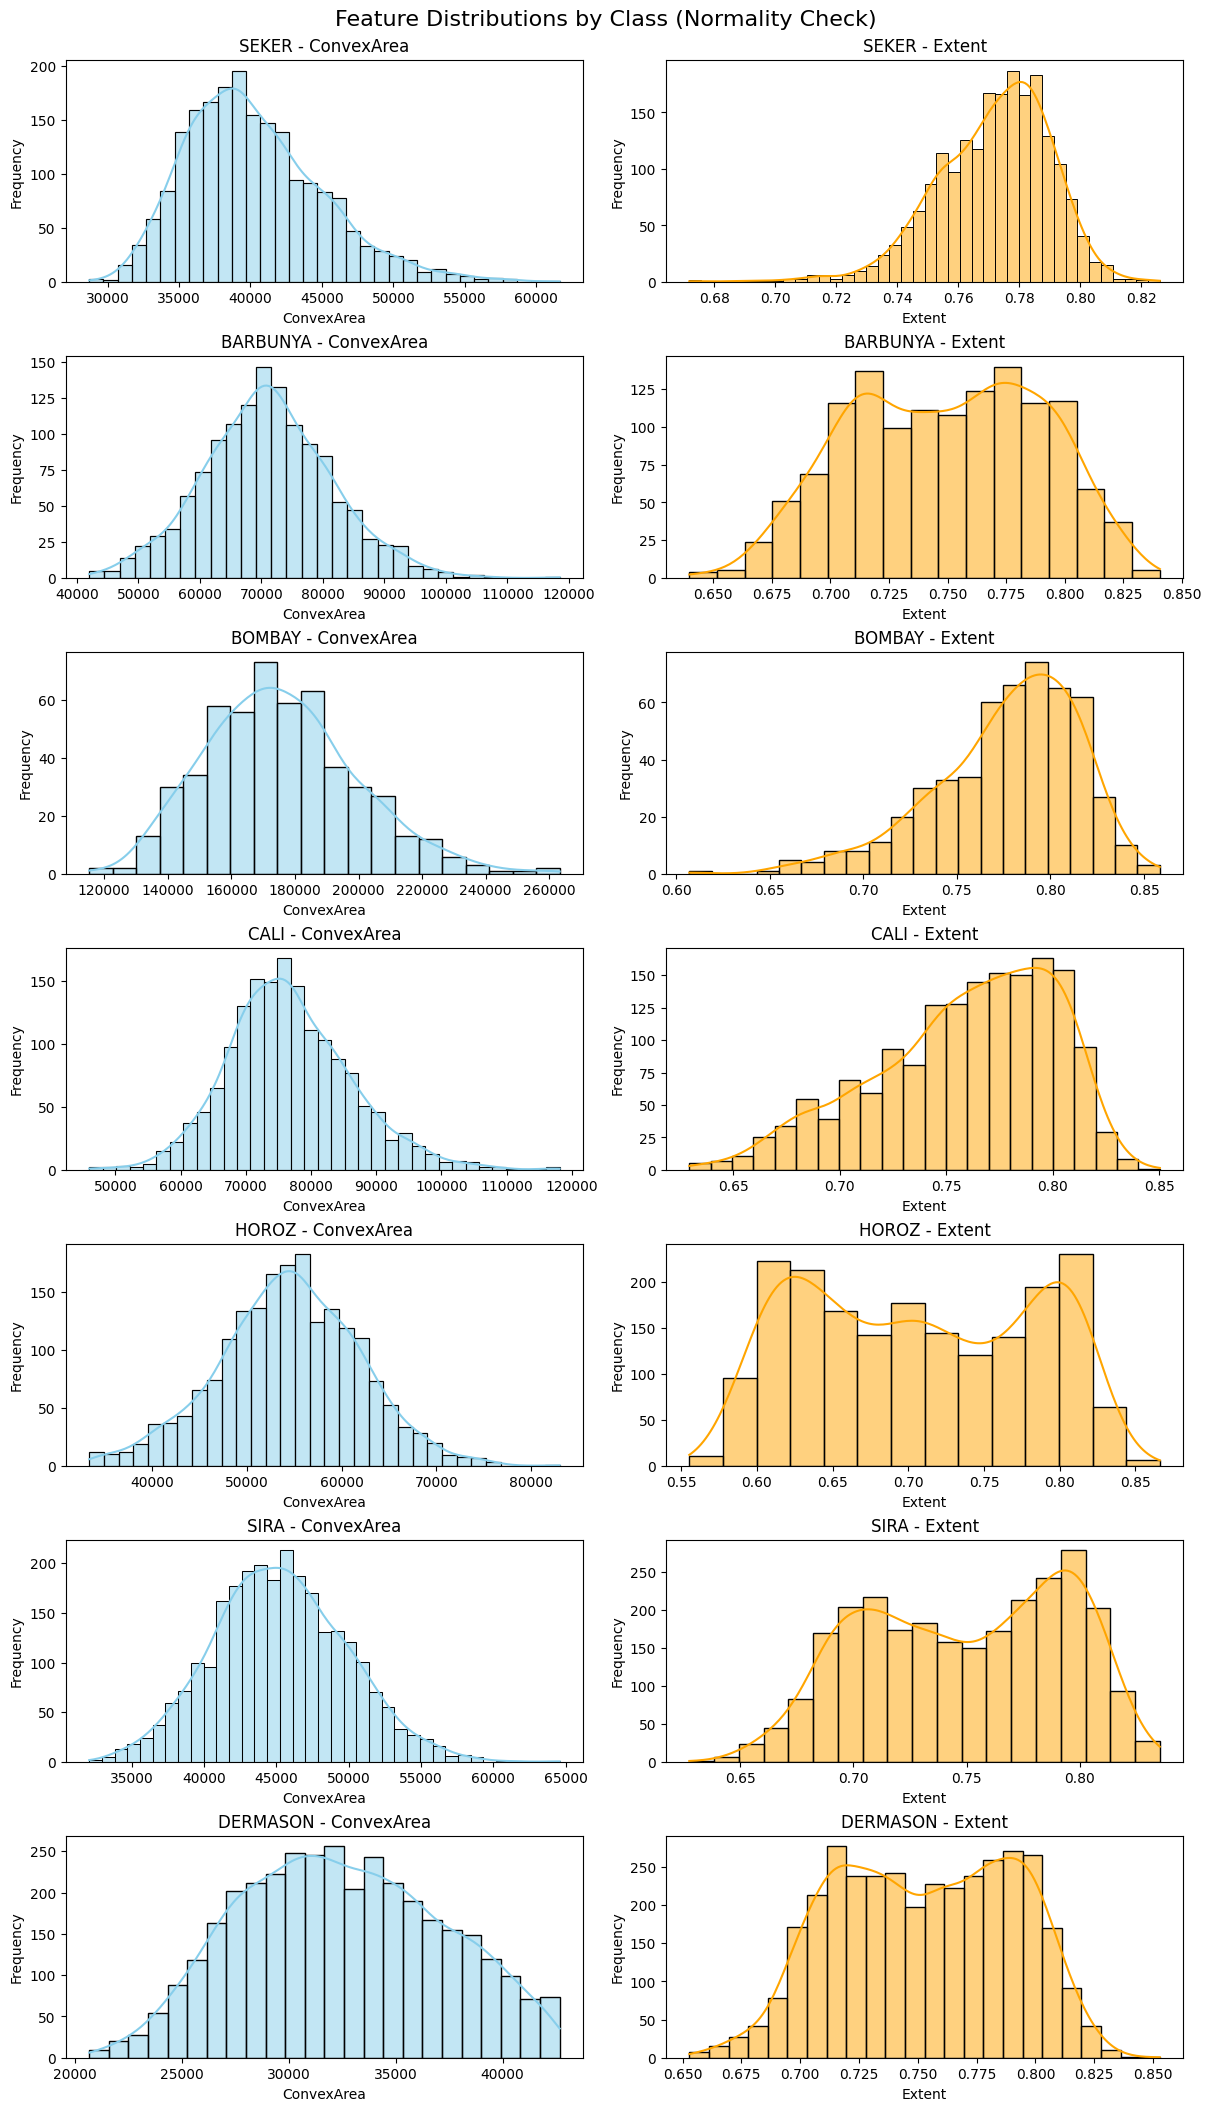

In [7]:
# 1. Get the list of unique classes to determine grid size
unique_classes = df['Class'].unique()
n_classes = len(unique_classes)

# 2. Create a subplot matrix: Rows = Classes, Cols = 2 Features
# We increase 'figsize' height to accommodate all rows
fig, axes = plt.subplots(nrows=n_classes, ncols=2, figsize=(12, 3 * n_classes), constrained_layout=True)

# 3. Loop through every class and plot its specific distribution
for i, species in enumerate(unique_classes):
    # Filter data for just this one species
    subset = df[df['Class'] == species]

    # --- Plot ConvexArea (Column 0) ---
    sns.histplot(data=subset, x='ConvexArea', kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'{species} - ConvexArea')
    axes[i, 0].set_ylabel('Frequency')

    # --- Plot Extent (Column 1) ---
    sns.histplot(data=subset, x='Extent', kde=True, ax=axes[i, 1], color='orange')
    axes[i, 1].set_title(f'{species} - Extent')
    axes[i, 1].set_ylabel('Frequency')

# Add a global title (optional)
fig.suptitle('Feature Distributions by Class (Normality Check)', fontsize=16)

plt.show()

The ```ConvexArea``` of all ```Class``` appears to be normally distributed.

```Extent``` is a bit different. For half ```Class```, there are left-skewwed distributions. The other half there appears to be a multi-modal distribution (two humps).

In [8]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [9]:
## Feature Selection (ConvexArea, Extent) + Target

X = df[["ConvexArea", "Extent"]].copy()
y = df["Class"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (13611, 2)
y shape: (13611,)


***End EDA***

---

## KNN Analysis and objectives:
* ```random_state = 2026``` everywhere
* Split 70% train / 20% val / 10% test with ```stratify=y``` (and ```stratify=y_temp```)
* Print partition shapes.
* Time complexity
* ```%%time``` used for EVERY .fit() operation (baseline + tuning).
* kNN on UNSCALED and SCALED data + decision boundaries for both
* ```StandardScaler``` fitted on train only; transforms val/test
* Hyperparameter tuning for k (3,5,7,9} using validation; select best; plot final boundary.

In [10]:
## Load Dataset
df = pd.read_excel("/content/Dry_Bean_Dataset.xlsx")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


Create the splits:
* Training 70%
* Validating 20%
* Testing 10%
* ```stratify=y```

In [11]:
## Partition Data (70/20/10) with Stratification + Print Shapes
# 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

# temp -> 20% val, 10% test (i.e., split temp 2/3 vs 1/3)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=1/3,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train shape:", X_train.shape, y_train.shape)  # ~70%
print("Val   shape:", X_val.shape, y_val.shape)      # ~20%
print("Test  shape:", X_test.shape, y_test.shape)    # ~10%

Train shape: (9527, 2) (9527,)
Val   shape: (2722, 2) (2722,)
Test  shape: (1362, 2) (1362,)


### Analytical Task: Why Stratify
* Stratification preserves the class distribution in each split.
* Without stratification, minority bean classes can be underrepresented in validation/testing
* making k-selection unstable and test performance estimates biased or misleading

**Time Complexity (BEFORE ANY FITTING)**

**TIME COMPLEXITY** — kNN (Theoretical, Before Execution)

Let:
n = number of training observations
d = number of features (d = 2 here)
k = number of neighbors

**TRAINING** (lazy learning):
• Stores data only
• Time: O(1)

**PREDICTION** per instance:
• Distance computations: O(n·d)
• Sorting distances: O(n log n)  (or partial selection ~ O(n) with selection algorithms)
• Choose k neighbors: O(k)

Overall (common implementation):
O(n·d + n log n)

StandardScaler:
• Fit: O(n·d)
• Transform: O(n·d)

Scaling improves distance validity but does not change kNN asymptotic complexity.

In [12]:
## Decision Boundary Function (2D)

def plot_decision_boundary(model, X_plot, y_plot, title, grid_points=220):
    le = LabelEncoder()
    y_enc = le.fit_transform(y_plot)

    x0 = X_plot.iloc[:, 0].to_numpy()
    x1 = X_plot.iloc[:, 1].to_numpy()

    x0_min, x0_max = x0.min(), x0.max()
    x1_min, x1_max = x1.min(), x1.max()

    pad0 = 0.02 * (x0_max - x0_min)
    pad1 = 0.02 * (x1_max - x1_min)

    xx0, xx1 = np.meshgrid(
        np.linspace(x0_min - pad0, x0_max + pad0, grid_points),
        np.linspace(x1_min - pad1, x1_max + pad1, grid_points)
    )

    grid = pd.DataFrame(np.c_[xx0.ravel(), xx1.ravel()], columns=X_plot.columns)

    Z_labels = model.predict(grid)
    Z = le.transform(Z_labels).reshape(xx0.shape)

    plt.figure()
    plt.contourf(xx0, xx1, Z, alpha=0.25)
    plt.scatter(x0, x1, c=y_enc, s=8)
    plt.xlabel(X_plot.columns[0])
    plt.ylabel(X_plot.columns[1])
    plt.title(title)
    plt.show()

In [13]:
## Baseline kNN (UNSCALED, k=5) — FIT TIME REQUIRED
%%time
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)

CPU times: user 22.4 ms, sys: 0 ns, total: 22.4 ms
Wall time: 23.2 ms


KNeighborsClassifier()

UNSCALED validation accuracy: 0.5757


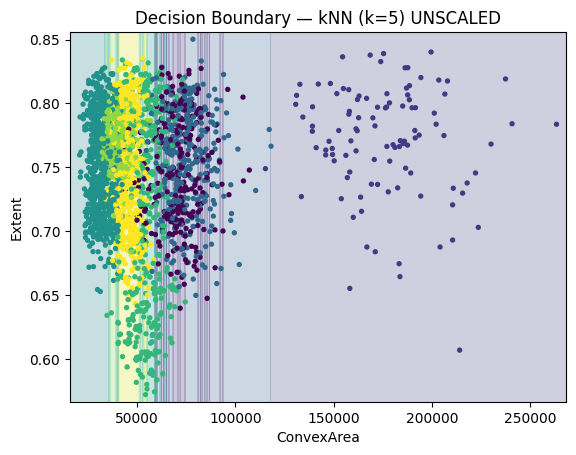

In [14]:
## Baseline Validation + Boundary (UNSCALED)
val_pred_unscaled = knn_unscaled.predict(X_val)
print("UNSCALED validation accuracy:", round(accuracy_score(y_val, val_pred_unscaled), 4))

plot_decision_boundary(
    knn_unscaled, X_val, y_val,
    title="Decision Boundary — kNN (k=5) UNSCALED"
)

Standardize Features (fit on train only)

In [15]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

X_train_s = pd.DataFrame(X_train_s, columns=X_train.columns)
X_val_s   = pd.DataFrame(X_val_s, columns=X_train.columns)
X_test_s  = pd.DataFrame(X_test_s, columns=X_train.columns)

Baseline kNN (SCALED, k=5) - FIT TIME REQUIRED

In [16]:
%%time
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_s, y_train)

CPU times: user 21.1 ms, sys: 2.89 ms, total: 24 ms
Wall time: 28.6 ms


KNeighborsClassifier()

Baseline Validation + Boundary (SCALED)

SCALED validation accuracy: 0.6506


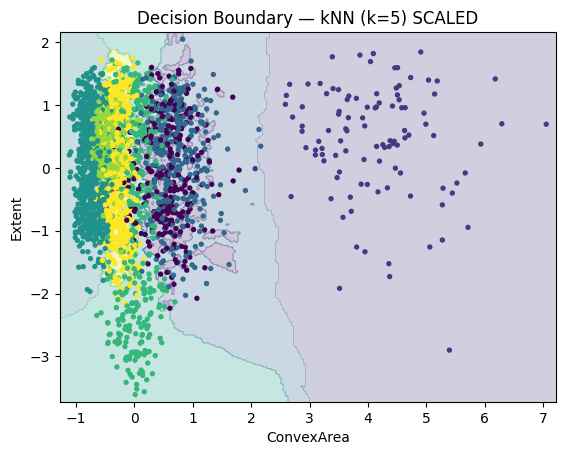

In [25]:
val_pred_scaled = knn_scaled.predict(X_val_s)
print("SCALED validation accuracy:", round(accuracy_score(y_val, val_pred_scaled), 4))

plot_decision_boundary(
    knn_scaled, X_val_s, y_val,
    title="Decision Boundary — kNN (k=5) SCALED"
)

**Technical Justification: Why Scaling Matters**

KNN uses distance (Euclidean/Minkowski). If features are on different numeric scales, the larger-scale feature (```ConvexArea```) dominates the distance computation, effectively down-weighting the smaller-scale feature (```Extent```). ```StandardScaler``` puts both on comparable scale so both contribute meaningfully to neighbor selection.

**Hyperparamerter tuning (k ∈ {3,5,7,9}) ~ VALIDATION SET**

In [18]:
## FIT k=3 (SCALED) — FIT TIME REQUIRED
%%time
knn_k3 = KNeighborsClassifier(n_neighbors=3)
knn_k3.fit(X_train_s, y_train)

CPU times: user 24.1 ms, sys: 0 ns, total: 24.1 ms
Wall time: 30.6 ms


KNeighborsClassifier(n_neighbors=3)

In [19]:
## FIT k=5 (SCALED) — FIT TIME REQUIRED
%%time
knn_k5 = KNeighborsClassifier(n_neighbors=5)
knn_k5.fit(X_train_s, y_train)

CPU times: user 23.1 ms, sys: 0 ns, total: 23.1 ms
Wall time: 28 ms


KNeighborsClassifier()

In [20]:
## FIT k=7 (SCALED) — FIT TIME REQUIRED
%%time
knn_k7 = KNeighborsClassifier(n_neighbors=7)
knn_k7.fit(X_train_s, y_train)

CPU times: user 23.1 ms, sys: 0 ns, total: 23.1 ms
Wall time: 29.1 ms


KNeighborsClassifier(n_neighbors=7)

In [21]:
## FIT k=9 (SCALED) — FIT TIME REQUIRED
%%time
knn_k9 = KNeighborsClassifier(n_neighbors=9)
knn_k9.fit(X_train_s, y_train)

CPU times: user 22.6 ms, sys: 937 µs, total: 23.6 ms
Wall time: 30.5 ms


KNeighborsClassifier(n_neighbors=9)

k=3 | validation accuracy=0.6194
k=5 | validation accuracy=0.6506
k=7 | validation accuracy=0.6594
k=9 | validation accuracy=0.6716

Best k based on validation: 9


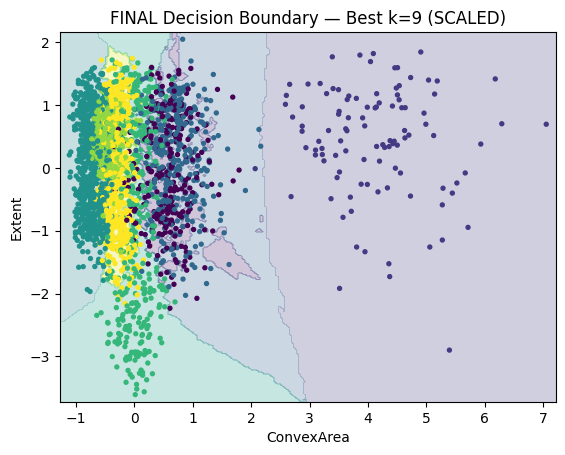

In [26]:
## Validate all k, pick best, plot final boundary
models = {3: knn_k3, 5: knn_k5, 7: knn_k7, 9: knn_k9}

val_acc = {}
for k, m in models.items():
    acc = accuracy_score(y_val, m.predict(X_val_s))
    val_acc[k] = acc
    print(f"k={k} | validation accuracy={acc:.4f}")

best_k = max(val_acc, key=val_acc.get)
best_model = models[best_k]

print("\nBest k based on validation:", best_k)

plot_decision_boundary(
    best_model, X_val_s, y_val,
    title=f"FINAL Decision Boundary — Best k={best_k} (SCALED)"
)

In [23]:
## Final Test Evaluation (Best Model)
test_pred = best_model.predict(X_test_s)
print("FINAL TEST accuracy:", round(accuracy_score(y_test, test_pred), 4))

FINAL TEST accuracy: 0.6733


### ANALYSIS CONCLUSION FOR KNN:

In the k-Nearest Neighbors analysis using ```ConvexArea``` and ```Extent``` from the Dry Bean dataset, model performance depended mostly on preprocessing and the choice of neighborhood size, not on model fitting. This matches kNN’s approach as a *lazy*, instance-based learner. Since kNN does not train before making predictions, using unscaled features caused distance calculations to be inaccurate and led to a low validation accuracy of $0.5757$, mainly because ```ConvexArea``` had a larger numeric range. After standardizing the features, validation accuracy improved to $0.6506$, showing that proper feature scaling is important for finding meaningful neighbors. Testing different neighborhood sizes showed that accuracy improved as $k$ increased, with the best result at $k = 9$. This gave a validation accuracy of $0.6716$ and a similar test accuracy of $0.6733$, which suggests the model generalized well and did not overfit. Overall, these results show that kNN can model local patterns in the data, but its lazy-learning method makes it very sensitive to feature scaling and the choice of hyperparameters.

***End Question 1 kNN Implementation***

---

# Question 2.1: Multimodel Implementation

Implement the remaining classification models from the course materials on the same
**standardized** training data:

1. **Generative Models**: Fit a **Gaussian Naive Bayes (GNB)** model and a **Linear Discriminant Analysis (LDA)** model.
    * Plot the decision boundary for each.
    * Analytical Task: Compare the boundaries. Based on the sources, how does the shared covariance matrix assumption in LDA result in a different boundary compared to GNB’s feature independence assumption?

## Linear Discriminant Model

For this assignment, only ```ConvexArea``` and ```Extent``` will be used as input features.

In [27]:
# Read the dataset from a Excel file
beans = pd.read_excel('/content/Dry_Bean_Dataset.xlsx')
beans.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


Standardization is necessary for LDA.

In [28]:
# Standardize input features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,ConvexArea,Extent
0,-0.841451,0.289087
1,-0.826102,0.697477
2,-0.808704,0.578195
3,-0.773975,0.671260
4,-0.784286,0.476020


Now that the input and output features are preprocessed, I need to create a ```train_test_split()``` with:
* Training 70%
* Validating 20%
* Testing 10%
* ```stratify=y```

In [29]:
# STEP 1: Split distinct Training data (70%) from the "Temp" data (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.3,   # 30% goes to temp
    random_state=2026,
    stratify=y        # maintain class distribution
)

# STEP 2: Split the "Temp" data into Validation (20%) and Test (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=1/3, # 1/3 of the temp data goes to Test
    random_state=2026,
    stratify=y_temp   # maintain class distribution
)

print(f"Train Shape: {X_train.shape} ({len(X_train)/len(X_scaled):.0%})")
print(f"Validation Shape:   {X_val.shape}   ({len(X_val)/len(X_scaled):.0%})")
print(f"Test Shape:  {X_test.shape}  ({len(X_test)/len(X_scaled):.0%})")

Train Shape: (9527, 2) (70%)
Validation Shape:   (2722, 2)   (20%)
Test Shape:  (1362, 2)  (10%)


The split is complete. Now, **initialize** model. Use ```n_components=2``` to set the number of principle components to use for finding the *discriminant weights* to **2**. ```store_covariance=True``` to store the *covariance matrix* to compare to the Logistic Regression model later.

In [30]:
# Initialize LDA model
lda = LDA(n_components=2, store_covariance=True)

**Fit** model.

In [31]:
%%time
# Fit LDA model on Training data
lda.fit(X_train, np.ravel(y_train))

CPU times: user 31 ms, sys: 1.02 ms, total: 32 ms
Wall time: 52.6 ms


LinearDiscriminantAnalysis(n_components=2, store_covariance=True)

Make **predictions**. Use validation data.

In [32]:
# Predict the class labels for the validation set
y_pred = lda.predict(X_val)

This may not be part of the assignment. However, do we'll an evaluation. Code was generated from *Gemini*.

Validation Accuracy: 60.32%

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.42      0.37      0.39       265
      BOMBAY       1.00      0.99      1.00       105
        CALI       0.63      0.62      0.62       326
    DERMASON       0.71      0.92      0.81       709
       HOROZ       0.63      0.53      0.58       385
       SEKER       0.32      0.15      0.20       405
        SIRA       0.51      0.61      0.55       527

    accuracy                           0.60      2722
   macro avg       0.60      0.60      0.59      2722
weighted avg       0.57      0.60      0.58      2722



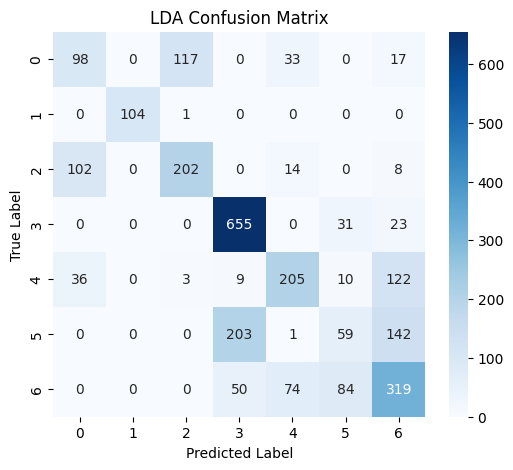

In [33]:
# Basic Accuracy
acc = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {acc * 100:.2f}%")

# Detailed Report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('LDA Confusion Matrix')
plt.show()

Plotting the **Decision Boundaries**. Code was generated from *Gemini*.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


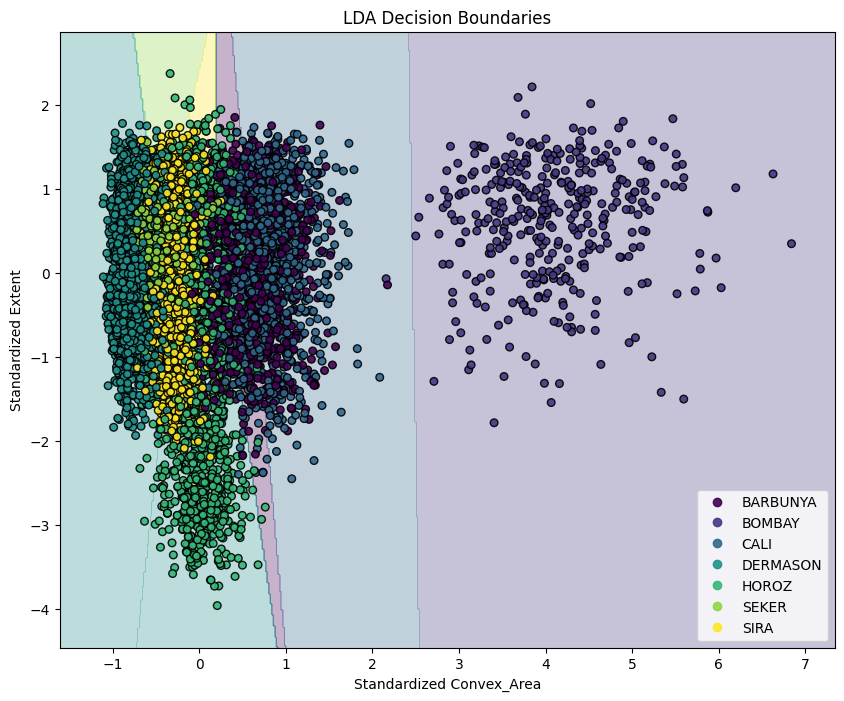

In [35]:
from matplotlib.colors import ListedColormap

# --- 1. SETUP HELPERS ---
le = LabelEncoder()
le.fit(y_train)

# *** THE FIX: Ensure we are working with NumPy arrays ***
# This prevents the "InvalidIndexError"
X_train_np = X_train.values if hasattr(X_train, 'values') else X_train

# --- 2. CREATE THE MESH GRID ---
# Now we use X_train_np which supports the [:, 0] syntax
x_min, x_max = X_train_np[:, 0].min() - 0.5, X_train_np[:, 0].max() + 0.5
y_min, y_max = X_train_np[:, 1].min() - 0.5, X_train_np[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# --- 3. PREDICT ---
Z_strings = lda.predict(np.c_[xx.ravel(), yy.ravel()])
Z_numeric = le.transform(Z_strings)
Z_numeric = Z_numeric.reshape(xx.shape)

# 1. Get the colors from the 'viridis' map directly
# We take 7 evenly spaced colors from the map
cmap_viridis = plt.get_cmap('viridis', 7)

plt.figure(figsize=(10, 8))

# 2. Use the SAME colormap for the background
# alpha=0.3 makes it pastel/lighter automatically
plt.contourf(xx, yy, Z_numeric, cmap=cmap_viridis, alpha=0.3)

# 3. Use the SAME colormap for the dots
scatter = plt.scatter(
    X_train_np[:, 0],
    X_train_np[:, 1],
    c=le.transform(y_train),
    cmap=cmap_viridis,  # <--- MATCHING MAP
    edgecolor='k',
    s=30,
    alpha=.9
)

plt.xlabel('Standardized Convex_Area')
plt.ylabel('Standardized Extent')
plt.title('LDA Decision Boundaries')
plt.legend(handles=scatter.legend_elements()[0], labels=list(le.classes_))

plt.show();

In [36]:
# Detailed Report (Precision, Recall, F1-Score)
print("\nClassification Report (LDA):")
print(classification_report(y_val, y_pred))


Classification Report (LDA):
              precision    recall  f1-score   support

    BARBUNYA       0.42      0.37      0.39       265
      BOMBAY       1.00      0.99      1.00       105
        CALI       0.63      0.62      0.62       326
    DERMASON       0.71      0.92      0.81       709
       HOROZ       0.63      0.53      0.58       385
       SEKER       0.32      0.15      0.20       405
        SIRA       0.51      0.61      0.55       527

    accuracy                           0.60      2722
   macro avg       0.60      0.60      0.59      2722
weighted avg       0.57      0.60      0.58      2722



***End LDA***

---

## Gaussian Naive Bayes Model

First, think about GNB **assumptions**:
1. All input features are independent and uncorrelated.
2. All input features are equally important.
3. Feature values ~ $Normal$ distribution.

We illustrated ***feature independence*** between ```Extent``` and ```ConvexArea``` in EDA.

Also, let's assume these features are ***equally important***.

The normality of ```ConvexArea``` is confirmed. However, the distributions of ```Extent``` are skewwed and/or multi-modal. This is not enough for me to discount this model, but must be taken into consideration when evaluating its performance.

**Initialize**

In [37]:
# Initialize the GNB model
gnb = GNB()

**Fit** using the same data split as the previous model.

In [38]:
%%time
# Fit the GNB model
gnb.fit(X_train, np.ravel(y_train))

CPU times: user 19 ms, sys: 4 µs, total: 19 ms
Wall time: 19 ms


GaussianNB()

This may not be part of the assignment. However, do we'll an evaluation.

--- Gaussian Naive Bayes Results ---
GNB Validation Accuracy: 67.74%

Classification Report (GNB):
              precision    recall  f1-score   support

    BARBUNYA       0.41      0.25      0.31       265
      BOMBAY       0.98      1.00      0.99       105
        CALI       0.59      0.71      0.64       326
    DERMASON       0.83      0.86      0.85       709
       HOROZ       0.71      0.70      0.71       385
       SEKER       0.54      0.55      0.54       405
        SIRA       0.63      0.65      0.64       527

    accuracy                           0.68      2722
   macro avg       0.67      0.67      0.67      2722
weighted avg       0.67      0.68      0.67      2722



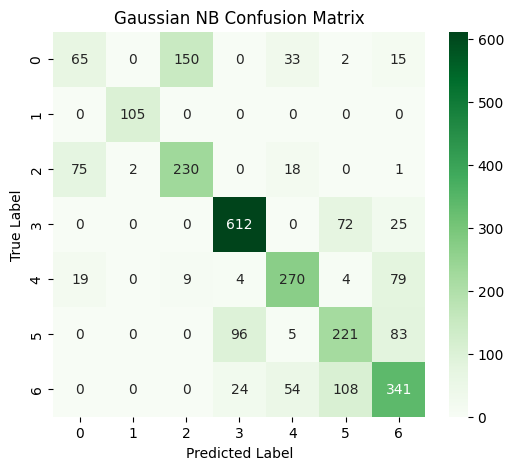

In [39]:
# 1. GENERATE NEW PREDICTIONS
# Critical: Ensure we call .predict() on the 'gnb' model, not 'lda'
y_pred_gnb = gnb.predict(X_val)

# 2. EVALUATE
print("--- Gaussian Naive Bayes Results ---")

# Accuracy
acc_gnb = accuracy_score(y_val, y_pred_gnb)
print(f"GNB Validation Accuracy: {acc_gnb * 100:.2f}%")

# 3. CLASSIFICATION REPORT
print("\nClassification Report (GNB):")
print(classification_report(y_val, y_pred_gnb))

# 4. CONFUSION MATRIX
cm_gnb = confusion_matrix(y_val, y_pred_gnb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Greens') # Changed color to Greens to distinguish from LDA
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Gaussian NB Confusion Matrix')
plt.show()

Plot the **Decision Boundaries**.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


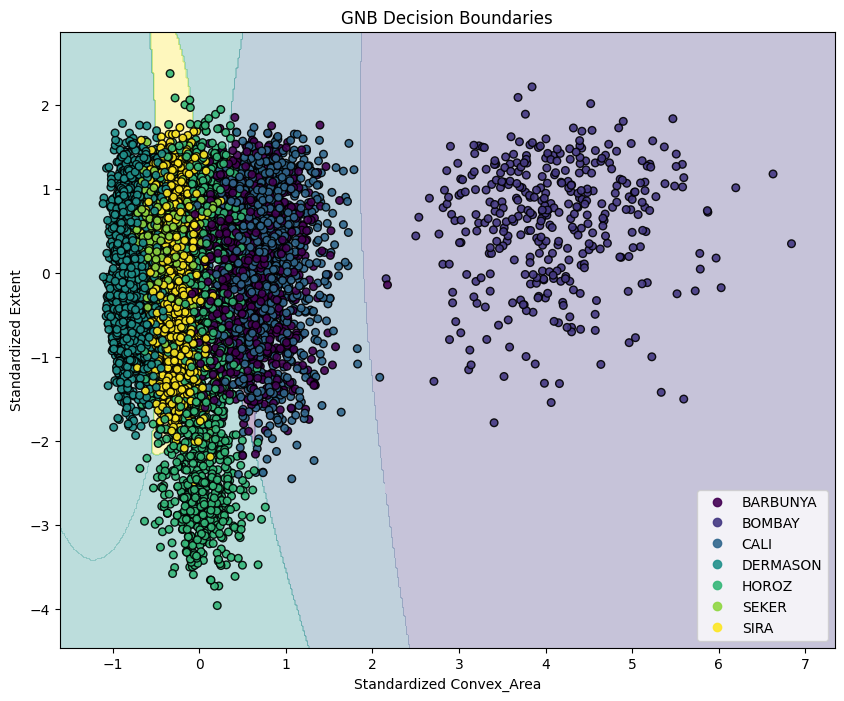

In [41]:
# --- 1. SETUP HELPERS ---
le = LabelEncoder()
le.fit(y_train)

# *** THE FIX: Ensure we are working with NumPy arrays ***
# This prevents the "InvalidIndexError"
X_train_np = X_train.values if hasattr(X_train, 'values') else X_train

# --- 2. CREATE THE MESH GRID ---
# Now we use X_train_np which supports the [:, 0] syntax
x_min, x_max = X_train_np[:, 0].min() - 0.5, X_train_np[:, 0].max() + 0.5
y_min, y_max = X_train_np[:, 1].min() - 0.5, X_train_np[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# --- 3. PREDICT ---
Z_strings = gnb.predict(np.c_[xx.ravel(), yy.ravel()])
Z_numeric = le.transform(Z_strings)
Z_numeric = Z_numeric.reshape(xx.shape)

# 1. Get the colors from the 'viridis' map directly
# We take 7 evenly spaced colors from the map
cmap_viridis = plt.get_cmap('viridis', 7)

plt.figure(figsize=(10, 8))

# 2. Use the SAME colormap for the background
# alpha=0.3 makes it pastel/lighter automatically
plt.contourf(xx, yy, Z_numeric, cmap=cmap_viridis, alpha=0.3)

# 3. Use the SAME colormap for the dots
scatter = plt.scatter(
    X_train_np[:, 0],
    X_train_np[:, 1],
    c=le.transform(y_train),
    cmap=cmap_viridis,  # <--- MATCHING MAP
    edgecolor='k',
    s=30,
    alpha=.9
)

plt.xlabel('Standardized Convex_Area')
plt.ylabel('Standardized Extent')
plt.title('GNB Decision Boundaries')
plt.legend(handles=scatter.legend_elements()[0], labels=list(le.classes_))

plt.show();

In [42]:
print("\nClassification Report (GNB):")
print(classification_report(y_val, y_pred_gnb))


Classification Report (GNB):
              precision    recall  f1-score   support

    BARBUNYA       0.41      0.25      0.31       265
      BOMBAY       0.98      1.00      0.99       105
        CALI       0.59      0.71      0.64       326
    DERMASON       0.83      0.86      0.85       709
       HOROZ       0.71      0.70      0.71       385
       SEKER       0.54      0.55      0.54       405
        SIRA       0.63      0.65      0.64       527

    accuracy                           0.68      2722
   macro avg       0.67      0.67      0.67      2722
weighted avg       0.67      0.68      0.67      2722



***End GNB***

---

## Comparison of LDA and GNB models

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


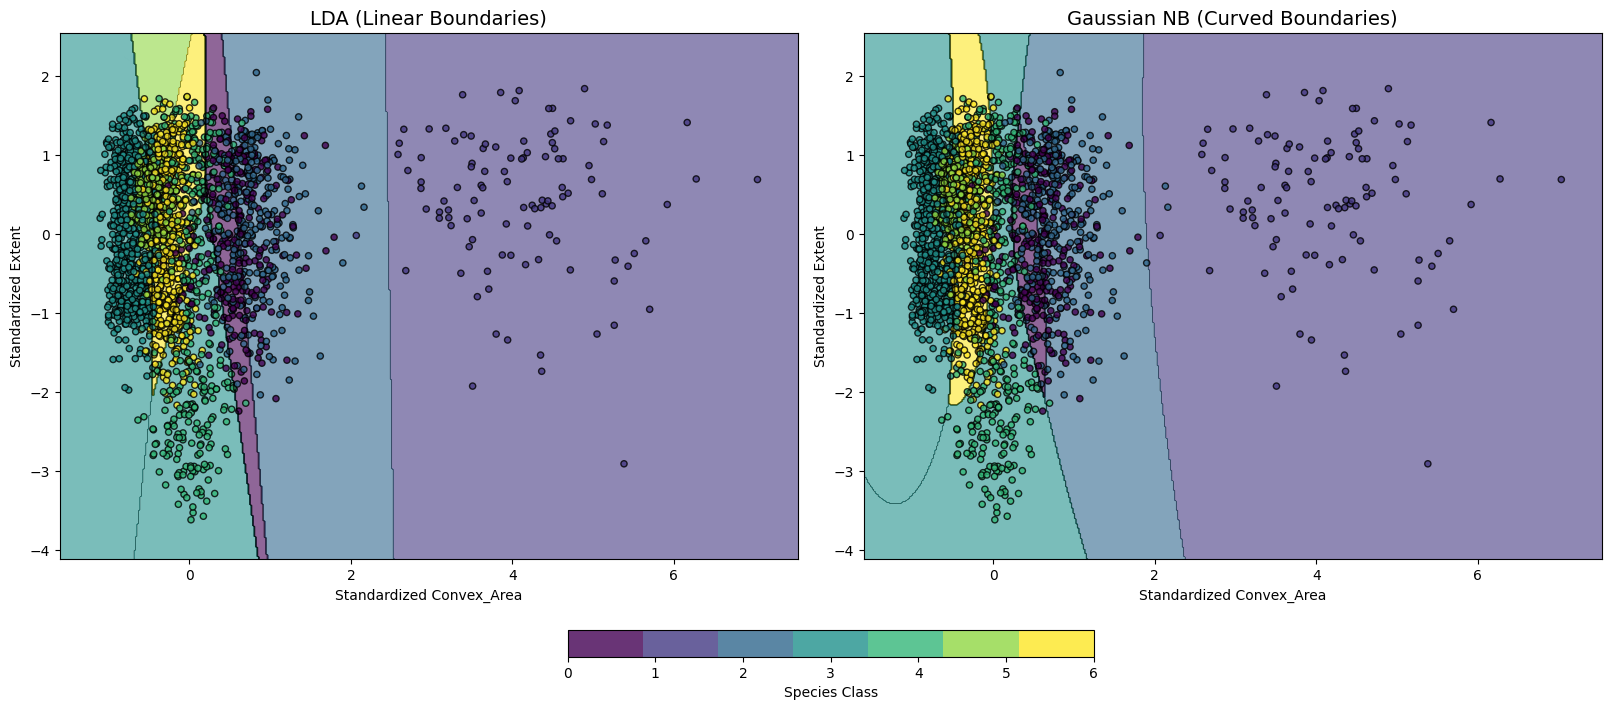

In [43]:
# --- 1. SETUP ---
# Ensure inputs are NumPy arrays
X = X_val.values if hasattr(X_val, 'values') else X_val
le = LabelEncoder()
y_enc = le.fit_transform(y_val)

# Create the Mesh Grid (The canvas)
# We only need to calculate this ONCE because both plots share the same x/y limits
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Setup Colors
# We use the same colors for both to make the comparison fair
#cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF', '#FFFFAA', '#FFAAFF', '#AAFFFF', '#CCCCCC'])
#cmap_bold = 'viridis'
cmap_viridis = plt.get_cmap('viridis', 7)

# --- 2. CREATE THE FIGURES ---
# This creates a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

# List of models and titles to loop through
models = [(lda, "LDA (Linear Boundaries)"),
          (gnb, "Gaussian NB (Curved Boundaries)")]

# --- 3. LOOP AND PLOT ---
for i, (model, title) in enumerate(models):
    # A. Predict the grid
    # We flatten the grid, predict, and reshape it back
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    # If the model returns strings, convert to numbers
    if Z.dtype.kind in {'U', 'S', 'O'}: # Check if string/object
        Z = le.transform(Z)

    Z = Z.reshape(xx.shape)

    # B. Plot on the specific axis (axes[i])
    ax = axes[i]

    # Contour (Background)
    ax.contourf(xx, yy, Z, cmap=cmap_viridis, alpha=0.6)
    ax.contour(xx, yy, Z, colors='k', linewidths=0.5, alpha=0.5)

    # Scatter (Data Points)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y_enc, cmap=cmap_viridis,
                         edgecolor='k', s=20, alpha=0.8)

    # Labels
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Standardized Convex_Area')
    ax.set_ylabel('Standardized Extent')

# Add a single legend for the whole figure
fig.colorbar(scatter, ax=axes, orientation='horizontal', fraction=0.05, pad=0.05, label='Species Class')

plt.show();

### Analytical Task:

#### Compare the boundaries.

The ```LDA``` boundaries are made of straight lines that criss cross the plot. The ```GNB``` boundaries are curved and attempt to draw the true shape of each ```Class``` cluster. I notice for the GNB boundaries, while slightly more accurate, they misclassify some of the correctly predicted classes.

For example: *BOMBAY* is perfectly classified by the ```LDA``` boundaries. In the ```GNB```, however, loses a prediction or two to the *CALI* class.

This is a minor tradeoff for what appears to be a slight increase in accuracy for predicting other classes.

#### Compare assumptions.

Based on the sources, how does the ***shared covariance matrix assumption*** in ```LDA``` result in a <u>different boundary</u> compared to ```GNB```’s ***feature independence assumption***?

In [44]:
print(lda.covariance_)

[[ 0.0691256  -0.00482901]
 [-0.00482901  0.83413005]]


The boundaries for each model are actually very similar. I learned that when the top right and bottom left values of the ```LDA``` covariance matrix are near $0$, it indicates that the **features are independent** of each other which is:
1. An assumption needed for ```GNB```.
2. Something I demonstrated in EDA.

This makes my ```LDA``` model behave very similarly to my ```GNB``` model.

**How do they differ?** ```LDA``` assumes that the covariance of every *Class* is **equal**. On the other hand, ```GNB``` assumes all variances ($\sigma^2$) are different. For example: *BOMBAY* is allowed to have a big puffy cloud while *DERMASON* has a tight cluster. Thus, each class is allowed to have its own unique boundary.

***End Question 2.1 LDA & GNB***

---

## Question 2.2 Multimodal Implementation

Implement the remaining classification models from the course materials on the same
**standardized** training data:

2. **Complexity & Non-Linearity**: Fit a **Quadratic Discriminant Analysis (QDA)** model.
    * Plot the decision boundary.
    * Analytical Task: Describe a scenario where QDA would likely outperform LDA based on how it handles class-specific covariance.

In [45]:
SEED = 2026

In [47]:
df=pd.read_excel("/content/Dry_Bean_Dataset.xlsx")

In [48]:
# Required features from the assignment
feature_cols = ["ConvexArea", "Extent"]

# Try to find the label column
possible_targets = ["Class", "class", "Species", "species", "Label", "label", "type", "Type"]
target_col = None
for c in possible_targets:
    if c in df.columns:
        target_col = c
        break

if target_col is None:
    raise ValueError(f"Could not find target column. Columns are: {list(df.columns)}")

# Keep only needed columns and drop missing rows
df2 = df[feature_cols + [target_col]].dropna().copy()

X = df2[feature_cols].values
y = df2[target_col].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class counts:\n", pd.Series(y).value_counts())

X shape: (13611, 2)
y shape: (13611,)
Class counts:
 DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


In [49]:
# STEP 1: Split Training data (70%) and Temp data (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,      # 30% goes to temp
    random_state=SEED,
    stratify=y           # maintain class distribution
)

# STEP 2: Split Temp data into Validation (20%) and Test (10%)
# 10% is 1/3 of the 30% temp data
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=1/3,       # 1/3 of temp → test
    random_state=SEED,
    stratify=y_temp
)

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Train Shape: {X_train.shape} ({len(X_train)/len(X):.0%})")
print(f"Val Shape:   {X_val.shape}   ({len(X_val)/len(X):.0%})")
print(f"Test Shape:  {X_test.shape}  ({len(X_test)/len(X):.0%})")

Train Shape: (9527, 2) (70%)
Val Shape:   (2722, 2)   (20%)
Test Shape:  (1362, 2)  (10%)


In [50]:
def time_fit(model, X, y, label="model"):
    start = time.perf_counter()
    model.fit(X, y)
    end = time.perf_counter()
    print(f"{label} fit time: {end - start:.6f} seconds")
    return model

In [51]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("Scaled train mean (approx):", X_train_s.mean(axis=0))
print("Scaled train std (approx): ", X_train_s.std(axis=0))

Scaled train mean (approx): [1.74801568e-17 2.89933994e-14]
Scaled train std (approx):  [1. 1.]


In [52]:
def plot_decision_boundary(model, X_plot, y_plot, title, ax=None, h=0.02):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
    y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = pd.Series(Z).astype("category").cat.codes.values  # numeric colors
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.30)

    # scatter actual points
    y_codes = pd.Series(y_plot).astype("category").cat.codes
    ax.scatter(X_plot[:, 0], X_plot[:, 1], c=y_codes, s=10)

    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    return ax

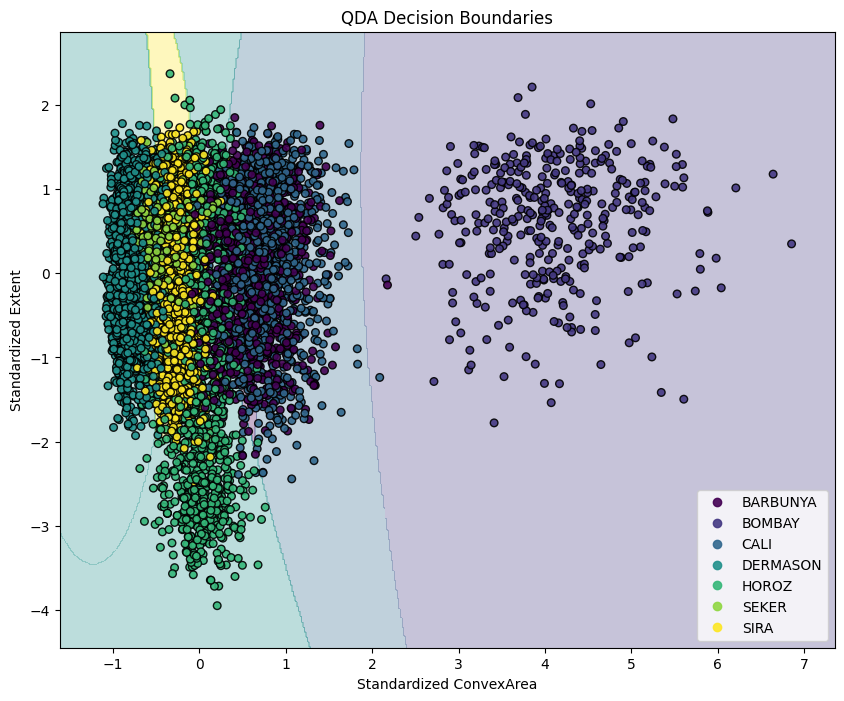

In [56]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_s, y_train)

# --- 2) Label encoding (for consistent colors) ---
le = LabelEncoder()
le.fit(y_train)

# Ensure numpy arrays
X_np = X_train_s.values if hasattr(X_train_s, "values") else X_train_s

# --- 3) Create mesh grid ---
x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# --- 4) Predict on the grid ---
Z_strings = qda.predict(np.c_[xx.ravel(), yy.ravel()])
Z_numeric = le.transform(Z_strings).reshape(xx.shape)

# --- 5) Plot (same colormap for background + points) ---
cmap_viridis = plt.get_cmap("viridis", len(le.classes_))

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z_numeric, cmap=cmap_viridis, alpha=0.3)

scatter = plt.scatter(
    X_np[:, 0],
    X_np[:, 1],
    c=le.transform(y_train),
    cmap=cmap_viridis,
    edgecolor="k",
    s=30,
    alpha=0.9
)

plt.xlabel("Standardized ConvexArea")
plt.ylabel("Standardized Extent")
plt.title("QDA Decision Boundaries")
plt.legend(handles=scatter.legend_elements()[0], labels=list(le.classes_))
plt.show()


**Question 2.2 Analytical Task**: Describe a scenario where QDA would likely outperform LDA?

Quadratic Discriminant Analysis (QDA) usually works better than Linear Discriminant Analysis (LDA) when different classes behave differently in terms of spread and shape in the data.

LDA assumes that all classes have the same overall spread and orientation in the feature space. Because of this assumption, it always creates straight (linear) decision boundaries. This works well when the classes are fairly similar in how their data points are distributed.

QDA does not make this assumption. Instead, it learns a separate spread (*covariance*) for each class. This allows QDA to adapt to differences between classes and create curved decision boundaries that better fit the data.

***End QDA***

---

## Question 2.3 Multimodal Implementation

3. **Discriminative Modeling**: Fit a **Logistic Regression** model (using ```penalty=None``` or ```penalty='l2'```).
    * Plot the decision boundary.
    * Interpretability Task: Retrieve the model weights (coefficients) and explain what they indicate about the contribution of ```ConvexArea``` and ```Extent``` to the classification

#### Plot the decision boundary

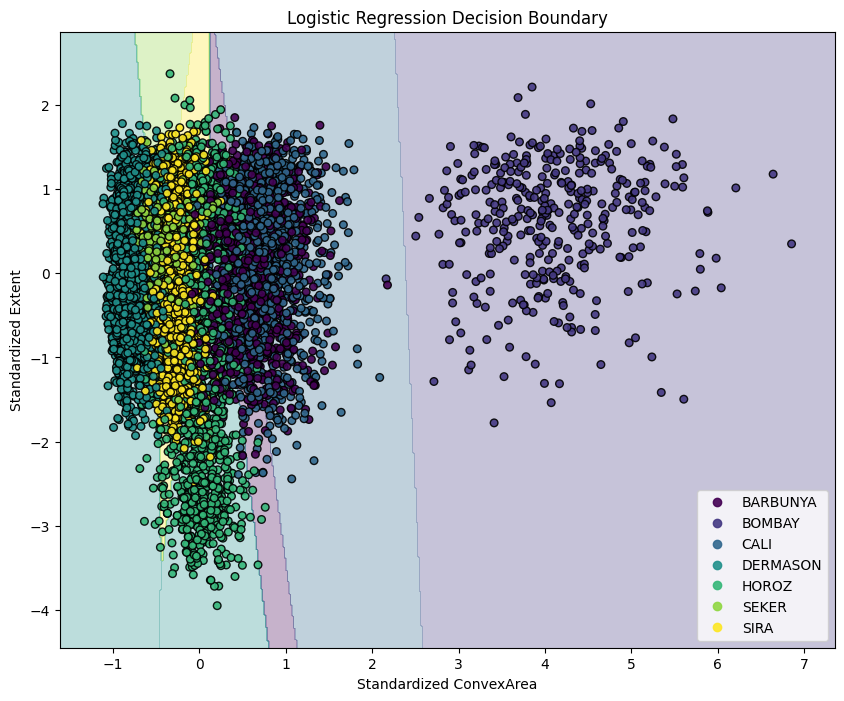

In [57]:
# --- 1) Fit Logistic Regression ---
# Use 'l2' (safe in all sklearn versions)
logreg = LogisticRegression(penalty='l2', max_iter=3000, random_state=SEED)
logreg.fit(X_train_s, y_train)

# --- 2) Label encoding for consistent colors ---
le = LabelEncoder()
le.fit(y_train)

X_np = X_train_s.values if hasattr(X_train_s, "values") else X_train_s

# --- 3) Mesh grid ---
x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# --- 4) Predict over grid ---
Z_strings = logreg.predict(np.c_[xx.ravel(), yy.ravel()])
Z_numeric = le.transform(Z_strings).reshape(xx.shape)

# --- 5) Plot ---
cmap_viridis = plt.get_cmap("viridis", len(le.classes_))

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z_numeric, cmap=cmap_viridis, alpha=0.3)

scatter = plt.scatter(
    X_np[:, 0],
    X_np[:, 1],
    c=le.transform(y_train),
    cmap=cmap_viridis,
    edgecolor="k",
    s=30,
    alpha=0.9
)

plt.xlabel("Standardized ConvexArea")
plt.ylabel("Standardized Extent")
plt.title("Logistic Regression Decision Boundary")
plt.legend(handles=scatter.legend_elements()[0], labels=list(le.classes_))
plt.show()

#### Question 2.3 Interpretability Task

**Question 2.3 Interpretability Task**: Retrieve the model weights (coefficients) and explain what they indicate about the contribution of ```ConvexArea``` and ```Extent``` to the classification.

In [58]:
print("Classes:", logreg.classes_)
print("coef_ shape:", logreg.coef_.shape)   # (num_classes, 2)
print("intercept_ shape:", logreg.intercept_.shape)

coef_df = pd.DataFrame(logreg.coef_, columns=["ConvexArea", "Extent"], index=logreg.classes_)
coef_df

Classes: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']
coef_ shape: (7, 2)
intercept_ shape: (7,)


,ConvexArea,Extent
BARBUNYA,6.969050,-0.042759
BOMBAY,12.264834,0.326524
CALI,8.564199,0.164416
DERMASON,-17.651821,-0.261526
HOROZ,1.581985,-0.662569
SEKER,-8.216125,0.559331
SIRA,-3.512122,-0.083417


From the table, ```ConvexArea``` clearly has the strongest impact on classification. For classes like *BOMBAY, CALI, and BARBUNYA*, the positive coefficients mean that beans with a larger ```ConvexArea``` are more likely to be classified into these groups. On the other hand, classes such as *DERMASON* and *SEKER* have large negative ```ConvexArea``` values, which means these beans tend to have smaller ```ConvexArea```.

The ```Extent``` feature has much smaller coefficient values, so it plays a supporting role rather than being the main deciding factor. Positive ```Extent``` values (for example in *SEKER* and *BOMBAY*) slightly increase the chance of predicting those classes, while negative values (such as in *HOROZ* and *DERMASON*) indicate that lower ```Extent``` values are more common for those beans.

Overall, the model mainly relies on ```ConvexArea``` to separate the bean classes, while ```Extent``` helps fine-tune the decision when classes are close to each other.

In [59]:
print("\n--- Feature meaning (DATA FEATURES, not weights) ---")
print("ConvexArea: Area of the convex hull around the bean (rubber-band area).")
print("Extent: Area / BoundingBoxArea (how much of the bounding box is filled).")

# ---- 1) Basic stats of raw features (before scaling) ----
X_raw = X_train.copy() if hasattr(X_train, "copy") else pd.DataFrame(X_train, columns=["ConvexArea", "Extent"])
if not isinstance(X_raw, pd.DataFrame):
    X_raw = pd.DataFrame(X_raw, columns=["ConvexArea", "Extent"])

print("\n--- Raw feature summary (train set) ---")
display(X_raw.describe().T)

# ---- 2) Scaling details (what StandardScaler did) ----
# Works if you used scaler = StandardScaler() earlier.
try:
    scaler_info = pd.DataFrame({
        "feature": ["ConvexArea", "Extent"],
        "scaler_mean_": scaler.mean_,
        "scaler_scale_(std)": scaler.scale_
    })
    print("\n--- StandardScaler parameters (fit on X_train) ---")
    display(scaler_info)
except NameError:
    print("\n[Warning] scaler not found. Run your StandardScaler cell first.")

# ---- 3) Logistic Regression weights (MODEL PARAMETERS) ----
feature_names = ["ConvexArea", "Extent"]

coef_df = pd.DataFrame(
    logreg.coef_,
    columns=feature_names,
    index=logreg.classes_
)

intercept_df = pd.DataFrame(
    logreg.intercept_,
    index=logreg.classes_,
    columns=["Intercept"]
)

print("\n--- Logistic Regression COEFFICIENTS (weights) on standardized features ---")
display(coef_df)

print("\n--- Logistic Regression INTERCEPTS ---")
display(intercept_df)

# ---- 4) Simple interpretation helpers ----
print("\n--- Which feature matters more (overall) ---")
overall_importance = coef_df.abs().mean().sort_values(ascending=False)
display(overall_importance)

print("\n--- Most influential feature per class (by absolute coefficient) ---")
top_per_class = coef_df.abs().idxmax(axis=1)
display(top_per_class.to_frame(name="TopFeature"))

print("\n--- Quick note ---")
print("Because features are standardized, larger |coefficient| means a stronger effect on the class score.")



--- Feature meaning (DATA FEATURES, not weights) ---
ConvexArea: Area of the convex hull around the bean (rubber-band area).
Extent: Area / BoundingBoxArea (how much of the bounding box is filled).

--- Raw feature summary (train set) ---


,count,mean,std,min,25%,50%,75%,max
ConvexArea,9527.0,53798.303348,29711.363820,20684.000000,36707.500000,45172.000000,62169.000000,257425.000000
Extent,9527.0,0.749532,0.049136,0.555315,0.718629,0.759553,0.786654,0.866195



--- StandardScaler parameters (fit on X_train) ---


,feature,scaler_mean_,scaler_scale_(std)
0,ConvexArea,53798.303348,29709.804455
1,Extent,0.749532,0.049133



--- Logistic Regression COEFFICIENTS (weights) on standardized features ---


...


--- Which feature matters more (overall) ---


,0
ConvexArea,8.394305
Extent,0.300077



--- Most influential feature per class (by absolute coefficient) ---


,TopFeature
BARBUNYA,ConvexArea
BOMBAY,ConvexArea
CALI,ConvexArea
DERMASON,ConvexArea
HOROZ,ConvexArea
SEKER,ConvexArea
SIRA,ConvexArea



--- Quick note ---
Because features are standardized, larger |coefficient| means a stronger effect on the class score.


In [60]:
# 1) Predictions on test set
y_pred = logreg.predict(X_test_s)

# 2) Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))

# 3) Precision, Recall, F1 (macro-averaged for multiclass)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("Precision (macro):", round(precision, 4))
print("Recall (macro):   ", round(recall, 4))
print("F1-score (macro): ", round(f1, 4))

# 4) Full per-class report (recommended for assignment)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6505
Precision (macro): 0.6512
Recall (macro):    0.6478
F1-score (macro):  0.6439

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.45      0.31      0.37       132
      BOMBAY       1.00      1.00      1.00        52
        CALI       0.62      0.75      0.68       163
    DERMASON       0.77      0.87      0.82       355
       HOROZ       0.67      0.60      0.63       193
       SEKER       0.45      0.32      0.38       203
        SIRA       0.59      0.69      0.64       264

    accuracy                           0.65      1362
   macro avg       0.65      0.65      0.64      1362
weighted avg       0.63      0.65      0.64      1362



In [61]:
%%time
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    penalty='l2',
    max_iter=3000,
    random_state=SEED
)

logreg.fit(X_train_s, y_train)

CPU times: user 284 ms, sys: 939 µs, total: 285 ms
Wall time: 160 ms


LogisticRegression(max_iter=3000, random_state=2026)

***End LogReg***

---

# Convert to HTML

In [1]:
# convert notebook(s) in the current directory to HTML
# (replace the wildcard with a specific filename if you prefer)
!jupyter nbconvert --to html '*.ipynb'

usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: kernel kernelspec migrate run troubleshoot

Jupyter command `jupyter-nbconvert` not found.
